<a href="https://colab.research.google.com/github/NikkithaS/exp-1-MLOps-/blob/main/GCRNN_STOCK_PRICE_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.5 MB/s eta 0:00:00


REGRESSION TASK

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
import yfinance as yf
from datetime import date
from scipy.spatial.distance import pdist, squareform

In [ ]:
START = "2010-01-01"
TODAY = date.today().strftime("%Y-%m-%d")

def load_data(ticker):
    data = yf.download(ticker, START, TODAY)
    data.reset_index(inplace=True)
    return data

In [ ]:
data = load_data('TCS.NS')

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
features = data[['Open', 'High', 'Low', 'Close', 'Volume']].values

In [ ]:
scaler_features = StandardScaler()
features = scaler_features.fit_transform(features)

In [ ]:
scaler_target = StandardScaler()
target = np.log1p(data[['Close']].values)
target = scaler_target.fit_transform(target).flatten()

In [ ]:
input_data = torch.tensor(features, dtype=torch.float32)
target_data = torch.tensor(target, dtype=torch.float32)

In [ ]:
distances = squareform(pdist(input_data.numpy(), metric="euclidean"))
threshold = np.percentile(distances, 20)
edge_index = torch.tensor(np.where(distances < threshold), dtype=torch.long)

<ipython-input-10-bc47c4833283>:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  edge_index = torch.tensor(np.where(distances < threshold), dtype=torch.long)


In [ ]:
class ImprovedGCRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(ImprovedGCRNN, self).__init__()
        self.gcn1 = SAGEConv(input_dim, hidden_dim)
        self.gcn2 = GATConv(hidden_dim, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.gcn1(x, edge_index)
        x = F.relu(x)
        x = self.gcn2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = x.unsqueeze(1)
        rnn_out, _ = self.rnn(x)
        out = self.fc(rnn_out[:, -1, :])
        return out.squeeze()

In [ ]:
num_samples = input_data.shape[0]
input_dim = input_data.shape[1]
hidden_dim = 64
output_dim = 1
num_epochs = 200
learning_rate = 0.001

In [ ]:
model = ImprovedGCRNN(input_dim, hidden_dim, output_dim)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
loss_fn = nn.MSELoss()

TRAINING

In [ ]:
losses = []
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    output = model(input_data, edge_index)
    loss = loss_fn(output.view(-1), target_data)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [20/200], Loss: 0.1947
Epoch [40/200], Loss: 0.0704
Epoch [60/200], Loss: 0.0427
Epoch [80/200], Loss: 0.0261
Epoch [100/200], Loss: 0.0192
Epoch [120/200], Loss: 0.0173
Epoch [140/200], Loss: 0.0150
Epoch [160/200], Loss: 0.0141
Epoch [180/200], Loss: 0.0141
Epoch [200/200], Loss: 0.0124


EVALUATION

In [ ]:
model.eval()
with torch.no_grad():
    predictions = model(input_data, edge_index)
    predictions_np = predictions.numpy()
    target_np = target_data.numpy()

    predictions_np = scaler_target.inverse_transform(predictions_np.reshape(-1, 1)).flatten()
    target_np = scaler_target.inverse_transform(target_np.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(target_np, predictions_np)
    mse = mean_squared_error(target_np, predictions_np)
    rmse = np.sqrt(mse)
    r2 = r2_score(target_np, predictions_np)

    print(f"GCRNN Metrics:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

GCRNN Metrics:
MAE: 0.0415
MSE: 0.0030
RMSE: 0.0549
R2 Score: 0.9951


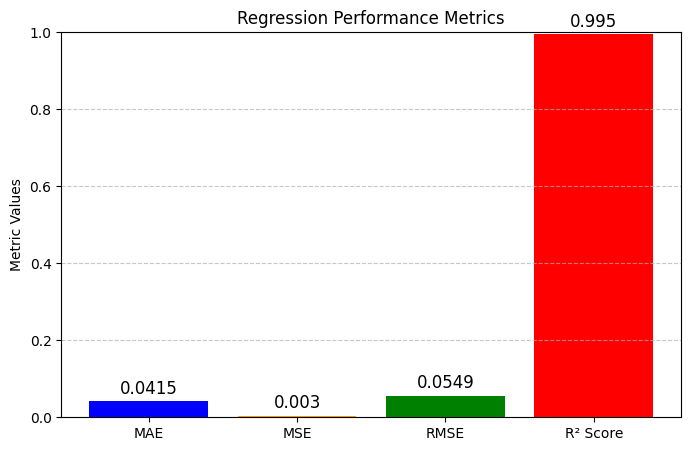

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Regression Metrics
metrics = ['MAE', 'MSE', 'RMSE', 'R² Score']
values = [0.0415, 0.0030, 0.0549, 0.995]  # Replace with your actual computed values

# Plot
plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])

# Adding values on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, str(round(v, 4)), ha='center', fontsize=12)

plt.ylabel("Metric Values")
plt.title("Regression Performance Metrics")
plt.ylim(0, 1)  # Adjusting Y-axis for better visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


VISUALIZATION

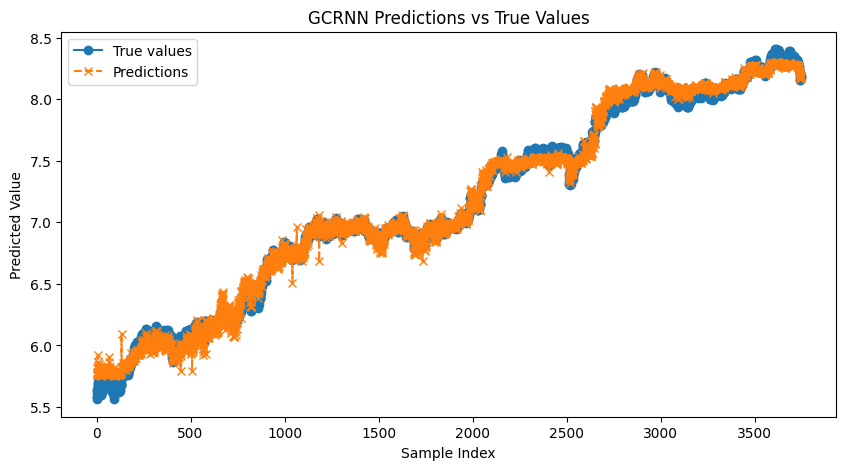

In [ ]:
    plt.figure(figsize=(10,5))
    plt.plot(target_np, label='True values', marker='o')
    plt.plot(predictions_np, label='Predictions', linestyle='dashed', marker='x')
    plt.xlabel("Sample Index")
    plt.ylabel("Predicted Value")
    plt.title("GCRNN Predictions vs True Values")
    plt.legend()
    plt.show()

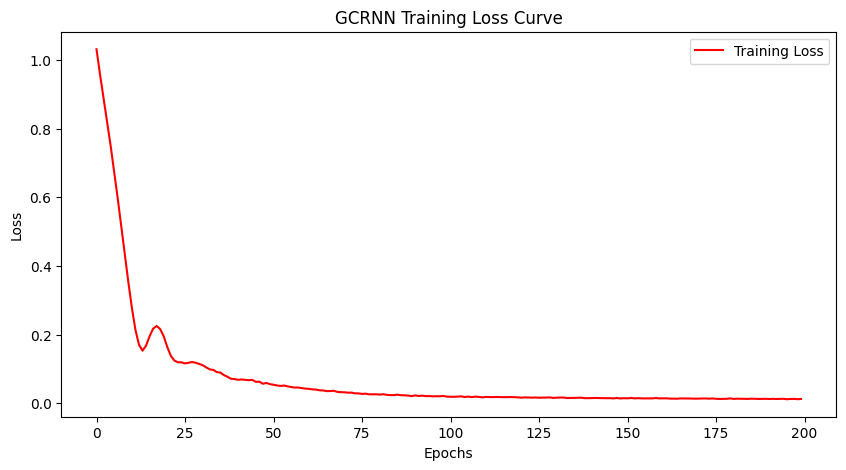

In [ ]:
    plt.figure(figsize=(10,5))
    plt.plot(losses, label='Training Loss', color='red')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("GCRNN Training Loss Curve")
    plt.legend()
    plt.show()

CLASSIFICATION

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Download stock data
ticker = "TCS.NS"
START = "2010-01-01"
TODAY = "2025-03-05"

data = yf.download(ticker, START, TODAY)
data.reset_index(inplace=True)

# Select features
features = data[['Open', 'High', 'Low', 'Close', 'Volume']].values

# Create target: 1 if price goes up, 0 if price goes down
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

# Standardize features
scaler = StandardScaler()
features = scaler.fit_transform(features)

# Encode labels
label_encoder = LabelEncoder()
target = label_encoder.fit_transform(data['Target'].dropna())  # Convert to categorical

# Convert to tensors
import torch
features = torch.tensor(features[:-1], dtype=torch.float32)
target = torch.tensor(target, dtype=torch.long)  # Must be LongTensor for classification


[*********************100%***********************]  1 of 1 completed


In [ ]:
import torch_geometric
from torch_geometric.data import Data

# Create edges (sequential graph: each node connected to previous one)
edge_index = torch.tensor(
    [[i, i + 1] for i in range(len(features) - 1)], dtype=torch.long
).t().contiguous()

# Create PyTorch Geometric Data object
graph_data = Data(x=features, edge_index=edge_index)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATConv

class ImprovedGCRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(ImprovedGCRNN, self).__init__()
        self.gcn1 = SAGEConv(input_dim, hidden_dim)
        self.gcn2 = GATConv(hidden_dim, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # Adjust for classification
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.gcn1(x, edge_index)
        x = F.relu(x)
        x = self.gcn2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        # Reshape for RNN
        x = x.unsqueeze(1)
        rnn_out, _ = self.rnn(x)
        out = self.fc(rnn_out[:, -1, :])
        return out  # No softmax (CrossEntropyLoss applies it)

In [ ]:
# Ensure features and target have the same length
features = features[:-1]  # Trim last row from features if needed
target = target[:features.shape[0]]  # Ensure target has the same length as features

# Convert to PyTorch tensors again
features = torch.tensor(features, dtype=torch.float32)
target = torch.tensor(target, dtype=torch.long)  # Classification labels

<ipython-input-100-f8d4c6dea70f>:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features = torch.tensor(features, dtype=torch.float32)
<ipython-input-100-f8d4c6dea70f>:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.long)  # Classification labels


In [ ]:
edge_index = torch.tensor(
    [[i, i + 1] for i in range(features.shape[0] - 1)], dtype=torch.long
).t().contiguous()

In [ ]:
from torch.optim import Adam
from sklearn.metrics import accuracy_score

# Model parameters
input_dim = features.shape[1]
hidden_dim = 64
output_dim = 2  # Classification (Up/Down)
num_epochs = 200
learning_rate = 0.001

# Model, optimizer, loss function
model = ImprovedGCRNN(input_dim, hidden_dim, output_dim)
optimizer = Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

# Training loop
losses = []
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    output = model(features, edge_index)  # Raw logits
    loss = loss_fn(output, target)  # Compute loss
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        pred_labels = torch.argmax(output, dim=1)
        accuracy = accuracy_score(target.numpy(), pred_labels.numpy())
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}")

Epoch [20/200], Loss: 0.6919, Accuracy: 0.5202
Epoch [40/200], Loss: 0.6907, Accuracy: 0.5279
Epoch [60/200], Loss: 0.6895, Accuracy: 0.5311
Epoch [80/200], Loss: 0.6898, Accuracy: 0.5381
Epoch [100/200], Loss: 0.6869, Accuracy: 0.5351
Epoch [120/200], Loss: 0.6843, Accuracy: 0.5488
Epoch [140/200], Loss: 0.6839, Accuracy: 0.5520
Epoch [160/200], Loss: 0.6803, Accuracy: 0.5667
Epoch [180/200], Loss: 0.6791, Accuracy: 0.5659
Epoch [200/200], Loss: 0.6794, Accuracy: 0.5589


In [ ]:
model.eval()
with torch.no_grad():
    predictions = model(features, edge_index)
    pred_labels = torch.argmax(predictions, dim=1).numpy()

    accuracy = accuracy_score(target.numpy(), pred_labels)
    print(f"Final Classification Accuracy: {accuracy:.4f}")

Final Classification Accuracy: 0.5677


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GATConv
from datetime import date
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Load dataset
START = "2010-01-01"
TODAY = date.today().strftime("%Y-%m-%d")

def load_data(ticker):
    data = yf.download(ticker, START, TODAY)
    data.reset_index(inplace=True)
    return data

data = load_data("TCS.NS")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
# Feature Engineering
data['Return'] = data['Close'].pct_change()
data.dropna(inplace=True)

features = data[['Open', 'High', 'Low', 'Close', 'Volume', 'Return']].values
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [ ]:
# Binary classification: 1 if price increased, 0 otherwise
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)
data.dropna(inplace=True)
target = data['Target'].values

In [ ]:
# Convert to PyTorch tensors
input_data = torch.tensor(features, dtype=torch.float32)
target_data = torch.tensor(target, dtype=torch.long)

In [ ]:
# Graph Construction (Dummy Edge Index for sequence)
num_samples = input_data.shape[0]
edge_index = torch.tensor([list(range(num_samples - 1)), list(range(1, num_samples))], dtype=torch.long)

In [ ]:
# Define GCRNN Model
class GCRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=2, dropout=0.2):
        super(GCRNN, self).__init__()
        self.gcn1 = SAGEConv(input_dim, hidden_dim)
        self.gcn2 = GATConv(hidden_dim, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.gcn1(x, edge_index)
        x = F.relu(x)
        x = self.gcn2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = x.unsqueeze(1)  # Reshape for RNN
        rnn_out, _ = self.rnn(x)
        out = self.fc(rnn_out[:, -1, :])
        return out

In [ ]:
# Model Training
input_dim = input_data.shape[1]
hidden_dim = 64
num_classes = 2
num_epochs = 200
learning_rate = 0.001

model = GCRNN(input_dim, hidden_dim, num_classes)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    output = model(input_data, edge_index)
    loss = loss_fn(output, target_data)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [20/200], Loss: 0.6899
Epoch [40/200], Loss: 0.6858
Epoch [60/200], Loss: 0.6798
Epoch [80/200], Loss: 0.6744
Epoch [100/200], Loss: 0.6670
Epoch [120/200], Loss: 0.6608
Epoch [140/200], Loss: 0.6518
Epoch [160/200], Loss: 0.6482
Epoch [180/200], Loss: 0.6446
Epoch [200/200], Loss: 0.6331


In [ ]:
# Evaluation
model.eval()
with torch.no_grad():
    output = model(input_data, edge_index)
    _, predicted_classes = torch.max(output, 1)
    accuracy = accuracy_score(target_data.numpy(), predicted_classes.numpy())
    print(f'Final Classification Accuracy: {accuracy:.4f}')

Final Classification Accuracy: 0.6429


---------------------------------------------

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
# Feature Engineering
features = data[['Open', 'High', 'Low', 'Close', 'Volume']].fillna(method='ffill')
scaler = StandardScaler()
X = scaler.fit_transform(features)

<ipython-input-71-6fea7b0dea37>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features = data[['Open', 'High', 'Low', 'Close', 'Volume']].fillna(method='ffill')


In [ ]:
# Label Processing (Binary Classification Example)
threshold = np.median(X[:, 3])  # Using median close price as threshold
y = (X[:, 3] > threshold).astype(int)  # 1 if above, 0 if below

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Handle Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
# Convert to Tensors
X_train, X_test = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32)
y_train, y_test = torch.tensor(y_train, dtype=torch.long), torch.tensor(y_test, dtype=torch.long)

In [ ]:
# Define GCRNN Model
class GCRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCRNN, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)
        self.bn = nn.BatchNorm1d(hidden_dim)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add sequence dimension
        out, _ = self.gru(x)
        out = self.bn(out[:, -1, :])  # Take last hidden state
        out = self.dropout(out)
        out = self.fc(out)
        return out

In [ ]:
# Initialize Model
input_dim = X_train.shape[1]
hidden_dim = 64
output_dim = len(set(y))
model = GCRNN(input_dim, hidden_dim, output_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

GCRNN(
  (gru): GRU(5, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [ ]:
# Loss and Optimizer (Handling Imbalance)
class_counts = torch.bincount(y_train)
class_weights = 1.0 / class_counts.float()
loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training Loop
def train_model(model, X_train, y_train, epochs=100):
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(X_train.to(device))
        loss = loss_fn(output, y_train.to(device))
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

train_model(model, X_train, y_train)

Epoch 0, Loss: 0.8283
Epoch 10, Loss: 0.2613
Epoch 20, Loss: 0.1931
Epoch 30, Loss: 0.1692
Epoch 40, Loss: 0.1544
Epoch 50, Loss: 0.1387
Epoch 60, Loss: 0.1294
Epoch 70, Loss: 0.1176
Epoch 80, Loss: 0.1082
Epoch 90, Loss: 0.1021


In [ ]:
# Evaluation
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        output = model(X_test.to(device))
        predictions = torch.argmax(output, dim=1).cpu().numpy()
        y_test_np = y_test.cpu().numpy()

    accuracy = accuracy_score(y_test_np, predictions)
    precision = precision_score(y_test_np, predictions, average='weighted')
    recall = recall_score(y_test_np, predictions, average='weighted')
    f1 = f1_score(y_test_np, predictions, average='weighted')
    cm = confusion_matrix(y_test_np, predictions)

    print(f"Final Classification Metrics:\nAccuracy: {accuracy:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", cm)

In [ ]:
# Run Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
evaluate_model(model, X_test, y_test)

Final Classification Metrics:
Accuracy: 0.9692
Precision: 0.9710
Recall: 0.9692
F1 Score: 0.9691
Confusion Matrix:
 [[373   0]
 [ 23 350]]


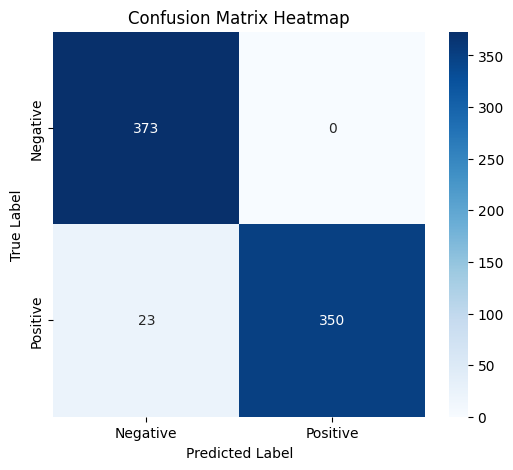

<ipython-input-85-9c38fd68adcf>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette="viridis")


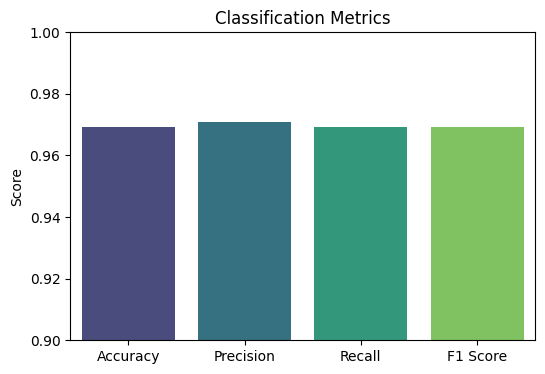

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix
conf_matrix = np.array([[373, 0], [23, 350]])

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

# Classification Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [0.9692, 0.9710, 0.9692, 0.9691]

plt.figure(figsize=(6, 4))
sns.barplot(x=metrics, y=values, palette="viridis")
plt.ylim(0.9, 1.0)  # Adjust y-axis range for better visibility
plt.ylabel("Score")
plt.title("Classification Metrics")
plt.show()
